In [1]:
import os
import json
import sqlite3
import time
import textwrap
 
import numpy as np
import faiss
import matplotlib.pyplot as plt
from PIL import Image
from sentence_transformers import SentenceTransformer
import whisper
import sounddevice as sd
from scipy.io.wavfile import write
 
print("All libraries imported successfully")


C:\Users\farha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



All libraries imported successfully


In [2]:
IMAGE_FOLDER    = "flickr8k/images"
CAPTION_FILE    = "flickr8k/captions_swe.txt"
 
SAVE_DIR        = "saved_models_2"
DB_PATH         = os.path.join(SAVE_DIR, "metadata.db")       # NEW: SQLite db
FAISS_PATH      = os.path.join(SAVE_DIR, "caption_index.faiss")
EMBED_MODEL_DIR = os.path.join(SAVE_DIR, "embedding_model")
WHISPER_PT      = os.path.join(SAVE_DIR, "whisper_model.pt")
CONFIG_PATH     = os.path.join(SAVE_DIR, "config.json")
 
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
WHISPER_MODEL   = "small"
BATCH_SIZE      = 64
RECORD_DURATION = 10
TOP_K           = 5
SCORE_THRESHOLD = 0.2
MAX_RETRIES     = 5
 
os.makedirs(SAVE_DIR, exist_ok=True)
print("Configuration loaded")

Configuration loaded


In [3]:
raw_captions    = []   # caption text
raw_image_paths = []   # matching image path
raw_ids         = []   # integer ID = row index
 
missing_count = 0
invalid_count = 0
 
with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    uid = 0
    for line in f:
        line = line.strip()
        if not line:
            continue
        if "," not in line:
            invalid_count += 1
            continue
 
        img_name, caption = line.split(",", 1)
        img_path = os.path.join(IMAGE_FOLDER, img_name.strip())
 
        if not os.path.exists(img_path):
            missing_count += 1
            continue
 
        caption = caption.strip().lower()
 
        raw_captions.append(caption)
        raw_image_paths.append(img_path)
        raw_ids.append(uid)
        uid += 1
 
print(f"Captions loaded : {len(raw_captions)}")
print(f"Missing images  : {missing_count}")
print(f"Invalid lines   : {invalid_count}")
 
# preview
for i in range(3):
    print(f"  [{raw_ids[i]}] {os.path.basename(raw_image_paths[i])} → {raw_captions[i]}")
 

Captions loaded : 40439
Missing images  : 15
Invalid lines   : 1
  [0] 1000268201_693b08cb0e.jpg → ett barn i en rosa klänning klättrar uppför en trappa i en entré.
  [1] 1000268201_693b08cb0e.jpg → en flicka går in i en träbyggnad.
  [2] 1000268201_693b08cb0e.jpg → en liten flicka som klättrar in i en lekstuga i trä.


In [4]:
conn = sqlite3.connect(DB_PATH)
conn.execute("DROP TABLE IF EXISTS captions")
conn.execute("""
    CREATE TABLE captions (
        id         INTEGER PRIMARY KEY,
        caption    TEXT    NOT NULL,
        image_path TEXT    NOT NULL,
        image_id   TEXT    NOT NULL
    )
""")
conn.execute("CREATE INDEX IF NOT EXISTS idx_image_id ON captions(image_id)")
 
rows = [
    (uid, caption, img_path, os.path.splitext(os.path.basename(img_path))[0])
    for uid, caption, img_path in zip(raw_ids, raw_captions, raw_image_paths)
]
conn.executemany("INSERT INTO captions VALUES (?,?,?,?)", rows)
conn.commit()
 
total = conn.execute("SELECT COUNT(*) FROM conn").fetchone()[0] if False else len(rows)
print(f"SQLite DB built  → {DB_PATH}")
print(f"  Rows inserted  : {len(rows)}")
print(f"  Unique images  : {len(set(raw_image_paths))}")

SQLite DB built  → saved_models_2\metadata.db
  Rows inserted  : 40439
  Unique images  : 8089


In [5]:
print(f"\nLoading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL)
print("Embedding model loaded")
 
EMBED_CACHE = os.path.join(SAVE_DIR, "caption_embeddings.npy")
 
if os.path.exists(EMBED_CACHE):
    print("Cache found — loading embeddings from disk...")
    caption_embeddings = np.load(EMBED_CACHE).astype("float32")
    print(f"Loaded {len(caption_embeddings)} embeddings from cache")
else:
    print("Encoding all captions (this may take a few minutes)...")
    caption_embeddings = embed_model.encode(
        raw_captions,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=BATCH_SIZE,
        convert_to_numpy=True,
    ).astype("float32")
    np.save(EMBED_CACHE, caption_embeddings)
    print(f"Embeddings saved to cache")
 
print(f"Embedding shape : {caption_embeddings.shape}")
 


Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2
Embedding model loaded
Encoding all captions (this may take a few minutes)...


Batches: 100%|███████████████████████████████████████████████████████████████████████| 632/632 [00:32<00:00, 19.69it/s]


Embeddings saved to cache
Embedding shape : (40439, 384)


In [6]:
assert len(caption_embeddings) == len(raw_ids), "Mismatch between embeddings and IDs"
 
dimension = caption_embeddings.shape[1]
n_vectors = len(caption_embeddings)
ids_array = np.array(raw_ids, dtype="int64")
 
print(f"Building FAISS IndexIDMap for {n_vectors} vectors (dim={dimension})...")
 
if n_vectors < 10_000:
    base_index = faiss.IndexFlatIP(dimension)
    print("  Using IndexFlatIP (exact search)")
else:
    n_clusters = min(200, n_vectors // 50)
    quantizer  = faiss.IndexFlatIP(dimension)
    base_index = faiss.IndexIVFFlat(
        quantizer, dimension, n_clusters, faiss.METRIC_INNER_PRODUCT
    )
    print(f"  Training IVFFlat with {n_clusters} clusters...")
    base_index.train(caption_embeddings)
    base_index.nprobe = 10
 
# Wrap with IDMap so we control the IDs
index = faiss.IndexIDMap(base_index)
index.add_with_ids(caption_embeddings, ids_array)
 
print(f"FAISS index built  → {index.ntotal} vectors")
assert index.ntotal == n_vectors, "Vector count mismatch after add"
print("All checks passed")

Building FAISS IndexIDMap for 40439 vectors (dim=384)...
  Training IVFFlat with 200 clusters...
FAISS index built  → 40439 vectors
All checks passed


In [7]:
import torch
 
# 1. Embedding model
embed_model.save(EMBED_MODEL_DIR)
print(f"Embedding model saved  → {EMBED_MODEL_DIR}/")
 
# 2. FAISS index
faiss.write_index(index, FAISS_PATH)
print(f"FAISS index saved      → {FAISS_PATH}")
 
# 3. Whisper model (load first if not already loaded)
if "speech_model" not in dir():
    print(f"Loading Whisper ({WHISPER_MODEL}) to save...")
    speech_model = whisper.load_model(WHISPER_MODEL)
 
torch.save(speech_model.state_dict(), WHISPER_PT)
print(f"Whisper model saved    → {WHISPER_PT}")
 
# 4. Config
config = {
    "EMBEDDING_MODEL" : EMBEDDING_MODEL,
    "WHISPER_MODEL"   : WHISPER_MODEL,
    "TOP_K"           : TOP_K,
    "SCORE_THRESHOLD" : SCORE_THRESHOLD,
    "RECORD_DURATION" : RECORD_DURATION,
    "MAX_RETRIES"     : MAX_RETRIES,
    "total_captions"  : n_vectors,
    "total_images"    : len(set(raw_image_paths)),
    "db_path"         : DB_PATH,
}
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)
print(f"Config saved           → {CONFIG_PATH}")
print("\nAll artifacts saved.")

Embedding model saved  → saved_models_2\embedding_model/
FAISS index saved      → saved_models_2\caption_index.faiss
Loading Whisper (small) to save...
Whisper model saved    → saved_models_2\whisper_model.pt
Config saved           → saved_models_2\config.json

All artifacts saved.


In [17]:
# ============================================================
# CELL 8 — Load everything back (inference session start)
# ============================================================
# Run this cell at the start of every new session instead of
# re-running Cells 3-7.
 
import sqlite3, json, faiss, torch, whisper, numpy as np
from sentence_transformers import SentenceTransformer
 
SAVE_DIR = "saved_models_2"
 
with open(os.path.join(SAVE_DIR, "config.json")) as f:
    config = json.load(f)
 
# embedding model
embed_model = SentenceTransformer(os.path.join(SAVE_DIR, "embedding_model"))
 
# whisper
speech_model = whisper.load_model(config["WHISPER_MODEL"])
speech_model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "whisper_model.pt"), map_location="cpu")
)
speech_model.eval()
 
# FAISS
index = faiss.read_index(os.path.join(SAVE_DIR, "caption_index.faiss"))
 
# SQLite  (read-only connection for inference)
conn = sqlite3.connect(os.path.join(SAVE_DIR, "metadata.db"))
 
# config values
TOP_K           = config["TOP_K"]
SCORE_THRESHOLD = config["SCORE_THRESHOLD"]
RECORD_DURATION = config["RECORD_DURATION"]
MAX_RETRIES     = config["MAX_RETRIES"]
 
print("="*50)
print("  All models loaded")
print(f"  FAISS vectors   : {index.ntotal}")
print(f"  Embed model     : {config['EMBEDDING_MODEL']}")
print(f"  Whisper         : {config['WHISPER_MODEL']}")
print(f"  TOP_K           : {TOP_K}")
print(f"  SCORE_THRESHOLD : {SCORE_THRESHOLD}")
print("="*50)

The tokenizer you are loading from 'saved_models_2\embedding_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  All models loaded
  FAISS vectors   : 40439
  Embed model     : paraphrase-multilingual-MiniLM-L12-v2
  Whisper         : small
  TOP_K           : 5
  SCORE_THRESHOLD : 0.2


In [9]:
# ============================================================
# CELL 9 — Metadata lookup helper
# ============================================================
# Single place that converts a FAISS id → caption + image_path.
# All search functions call this — nothing else touches SQLite directly.
 
def lookup(ids):
    """
    Given a list of integer FAISS ids, return list of dicts
    {id, caption, image_path, image_id}.
    Skips ids that are -1 (empty FAISS slot).
    """
    valid_ids = [int(i) for i in ids if i != -1]
    if not valid_ids:
        return []
 
    placeholders = ",".join("?" * len(valid_ids))
    rows = conn.execute(
        f"SELECT id, caption, image_path, image_id FROM captions WHERE id IN ({placeholders})",
        valid_ids,
    ).fetchall()
 
    # preserve FAISS score order
    order = {row[0]: row for row in rows}
    return [order[i] for i in valid_ids if i in order]

In [10]:
# ============================================================
# CELL 10 — display_results()
# ============================================================
def display_results(results, query):
    """
    Display retrieved images in a grid with captions and scores.
 
    Args:
        results : list of dicts from text_search() or speech_search()
        query   : original query string (shown as title)
    """
    if not results:
        print(f"No results found for: '{query}'")
        return
 
    n         = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
 
    fig.suptitle(f'Query: "{query}"', fontsize=13, fontweight="bold", y=1.02)
 
    for ax, r in zip(axes, results):
        try:
            img = Image.open(r["image_path"])
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center")
        ax.axis("off")
 
        caption_wrapped = textwrap.fill(r["caption"], width=28)
        score_pct       = r["score"] * 100
        ax.set_title(
            f"Score: {score_pct:.1f}%\n{caption_wrapped}",
            fontsize=7, pad=5, loc="center",
        )
 
    plt.tight_layout()
    plt.show()
 
    print(f"\nRetrieved {len(results)} images for: '{query}'")
    print("-" * 55)
    for i, r in enumerate(results):
        print(
            f"  {i+1}. Score={r['score']:.3f}"
            f" | {os.path.basename(r['image_path'])}"
            f" | {r['caption'][:50]}"
        )
    print("-" * 55)
 
print("display_results() ready")
 

display_results() ready


In [11]:
# ============================================================
# CELL 11 — text_search()
# ============================================================
def text_search(query, k=TOP_K, score_threshold=SCORE_THRESHOLD):
    """
    Search images using a Swedish text query.
 
    Args:
        query          : Swedish text string
        k              : number of images to return
        score_threshold: minimum similarity (0.0 to 1.0)
 
    Usage:
        text_search("en hund som springer")
        text_search("barn som leker", k=3)
    """
    if not query or not query.strip():
        print("Empty query — please type something")
        return []
 
    query = query.strip().lower()
    print(f"\nTEXT SEARCH: '{query}'")
    print(f"  Index: {index.ntotal} vectors | Top-K: {k} | Threshold: {score_threshold}")
 
    # encode
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")
 
    # search — fetch more to allow deduplication
    scores, faiss_ids = index.search(query_vec, k * 6)
 
    # build results — deduplicate on image_path via SQLite lookup
    results    = []
    seen_paths = set()
 
    score_map = {int(fid): float(sc) for sc, fid in zip(scores[0], faiss_ids[0])}
 
    for row in lookup(faiss_ids[0]):
        rid, caption, image_path, image_id = row
        score = score_map.get(rid, 0.0)
 
        if score < score_threshold:
            continue
        if image_path in seen_paths:
            continue
 
        seen_paths.add(image_path)
        results.append({
            "id"         : rid,
            "image_path" : image_path,
            "caption"    : caption,
            "score"      : score,
            "query"      : query,
            "source"     : "text",
        })
 
        if len(results) == k:
            break
 
    if results:
        print(f"Found {len(results)} results")
        display_results(results, query)
    else:
        print(f"No results found for '{query}'")
        print(f"  Try lowering score_threshold (current: {score_threshold})")
 
    return results
 
print("text_search() ready")

text_search() ready


In [12]:
# ============================================================
# CELL 12 — speech_search()
# ============================================================
def speech_search(duration=RECORD_DURATION, k=TOP_K, max_retries=MAX_RETRIES):
    """
    Search images using Swedish voice input.
    Records microphone → Whisper ASR → text_search()
 
    Usage:
        speech_search()
        speech_search(duration=7)
        speech_search(k=3)
    """
    recognized_query = None
 
    for attempt in range(max_retries):
        print(f"\n{'='*45}")
        print(f"  SPEECH SEARCH — Attempt {attempt+1}/{max_retries}")
        print(f"{'='*45}")
 
        # record
        print(f"\nSpeak in Swedish ({duration} seconds)")
        for i in range(3, 0, -1):
            print(f"  {i}...")
            time.sleep(1)
        print("  Recording — SPEAK NOW!")
 
        audio = sd.rec(
            int(duration * 16000),
            samplerate=16000,
            channels=1,
            dtype="float32",
        )
        sd.wait()
        print("  Recording stopped")
 
        rms = float(np.sqrt(np.mean(audio ** 2)))
        print(f"  Audio level: {rms:.4f}", end="  ")
 
        if rms < 0.001:
            print("Silent — check microphone")
            continue
        elif rms < 0.01:
            print("Quiet — speak louder next time")
        else:
            print("Good")
 
        # save wav — close handle before Whisper opens it (Windows fix)
        import tempfile
        tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
        tmp_path = tmp.name
        tmp.close()
        from scipy.io.wavfile import write as wav_write
        try:
            wav_write(tmp_path, 16000, audio)
            print("\nTranscribing with Whisper...")
            result = speech_model.transcribe(
                tmp_path,
                language="sv",
                task="transcribe",
                temperature=0.0,
                no_speech_threshold=0.6,
                logprob_threshold=-1.0,
            )
        finally:
            try:
                os.unlink(tmp_path)
            except Exception:
                pass
 
        text = result["text"].strip()
        if not text:
            print("No speech detected — try again")
            continue
 
        avg_logprob = -1.0
        if result.get("segments"):
            avg_logprob = result["segments"][0].get("avg_logprob", -1.0)
 
        confidence = min(100, max(0, (avg_logprob + 1.0) * 100))
        print(f"  Transcript : '{text}'")
        print(f"  Confidence : {confidence:.0f}%")
 
        if avg_logprob < -1.2:
            print("  Low confidence — trying again...")
            if attempt < max_retries - 1:
                continue
 
        recognized_query = text
        break
 
    if not recognized_query:
        print("\nVoice failed — falling back to text input")
        recognized_query = input("Type your Swedish query: ").strip()
        if not recognized_query:
            print("No query entered")
            return []
 
    return text_search(recognized_query, k=k, score_threshold=SCORE_THRESHOLD)
 
print("speech_search() ready")

speech_search() ready


In [13]:
# ============================================================
# CELL 13 — Add new images (no full rebuild needed)
# ============================================================
def add_images(new_caption_file):
    """
    Add new image-caption pairs to the existing index and DB.
    No full rebuild required — uses IndexIDMap.add_with_ids().
 
    Args:
        new_caption_file: path to a CSV file with lines:
                          image_filename,swedish caption
 
    Usage:
        add_images("new_images/captions_swe.txt")
    """
    # get current max id from DB
    max_id = conn.execute("SELECT MAX(id) FROM captions").fetchone()[0] or 0
    next_id = max_id + 1
 
    new_rows      = []
    new_captions  = []
    new_ids       = []
    missing       = 0
 
    with open(new_caption_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "," not in line:
                continue
            img_name, caption = line.split(",", 1)
            img_path = os.path.join(IMAGE_FOLDER, img_name.strip())
            if not os.path.exists(img_path):
                missing += 1
                continue
            caption = caption.strip().lower()
            image_id = os.path.splitext(img_name.strip())[0]
 
            new_rows.append((next_id, caption, img_path, image_id))
            new_captions.append(caption)
            new_ids.append(next_id)
            next_id += 1
 
    if not new_rows:
        print("No valid new captions found")
        return
 
    print(f"Encoding {len(new_captions)} new captions...")
    new_vecs = embed_model.encode(
        new_captions,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True,
    ).astype("float32")
    new_ids_arr = np.array(new_ids, dtype="int64")
 
    # insert into FAISS — no rebuild
    index.add_with_ids(new_vecs, new_ids_arr)
 
    # insert into SQLite — no rebuild
    conn.executemany("INSERT INTO captions VALUES (?,?,?,?)", new_rows)
    conn.commit()
 
    # overwrite FAISS file
    faiss.write_index(index, FAISS_PATH)
 
    print(f"Added {len(new_rows)} captions ({missing} images missing)")
    print(f"FAISS total now: {index.ntotal}")
    print(f"DB rows now    : {conn.execute('SELECT COUNT(*) FROM captions').fetchone()[0]}")
 
print("add_images() ready")

add_images() ready


In [14]:
# ============================================================
# CELL 14 — Delete images (no full rebuild needed)
# ============================================================
def delete_images(image_ids_to_remove):
    """
    Remove images from the index and DB by image_id.
    Uses FAISS remove_ids() — no full rebuild.
 
    Args:
        image_ids_to_remove: list of image_id strings
                             e.g. ["1000268", "2343215"]
 
    Usage:
        delete_images(["1000268", "2343215771"])
    """
    placeholders = ",".join("?" * len(image_ids_to_remove))
    rows = conn.execute(
        f"SELECT id FROM captions WHERE image_id IN ({placeholders})",
        image_ids_to_remove,
    ).fetchall()
 
    faiss_ids = np.array([r[0] for r in rows], dtype="int64")
 
    if len(faiss_ids) == 0:
        print("No matching image_ids found in DB")
        return
 
    # remove from FAISS
    selector = faiss.IDSelectorArray(faiss_ids)
    removed  = index.remove_ids(selector)
 
    # remove from SQLite
    conn.execute(
        f"DELETE FROM captions WHERE image_id IN ({placeholders})",
        image_ids_to_remove,
    )
    conn.commit()
 
    # save updated index
    faiss.write_index(index, FAISS_PATH)
 
    print(f"Removed {removed} vectors from FAISS")
    print(f"FAISS total now: {index.ntotal}")
    print(f"DB rows now    : {conn.execute('SELECT COUNT(*) FROM captions').fetchone()[0]}")
 
print("delete_images() ready")

delete_images() ready


In [15]:
# ============================================================
# CELL 15 — Evaluation
# ============================================================
def evaluate_system(test_queries, ground_truth_paths, k_values=[1, 5, 10]):
    """
    Evaluate retrieval quality with standard IR metrics.
 
    Args:
        test_queries       : list of Swedish query strings
        ground_truth_paths : correct image path for each query
        k_values           : Recall@K values to compute
 
    Metrics computed:
        Recall@K  — did correct image appear in top K?
        MRR       — Mean Reciprocal Rank
    """
    recall_scores = {k: [] for k in k_values}
    mrr_scores    = []
 
    print(f"Evaluating {len(test_queries)} queries...\n")
 
    for i, (query, gt_path) in enumerate(zip(test_queries, ground_truth_paths)):
        results         = text_search(query, k=max(k_values), score_threshold=0.0)
        retrieved_paths = [r["image_path"] for r in results]
 
        for k in k_values:
            recall_scores[k].append(int(gt_path in retrieved_paths[:k]))
 
        mrr = 0.0
        for rank, path in enumerate(retrieved_paths, start=1):
            if path == gt_path:
                mrr = 1.0 / rank
                break
        mrr_scores.append(mrr)
 
        if (i + 1) % 10 == 0:
            print(f"  Evaluated {i+1}/{len(test_queries)}...")
 
    print("\n" + "="*35)
    print("     EVALUATION RESULTS")
    print("="*35)
    for k in k_values:
        print(f"  Recall@{k:<3} : {np.mean(recall_scores[k])*100:.1f}%")
    print(f"  MRR       : {np.mean(mrr_scores):.4f}")
    print("="*35)
 
    return recall_scores, mrr_scores
 
print("evaluate_system() ready")

evaluate_system() ready



TEXT SEARCH: 'en flicka sitter nära väggen'
  Index: 40439 vectors | Top-K: 5 | Threshold: 0.2
Found 5 results


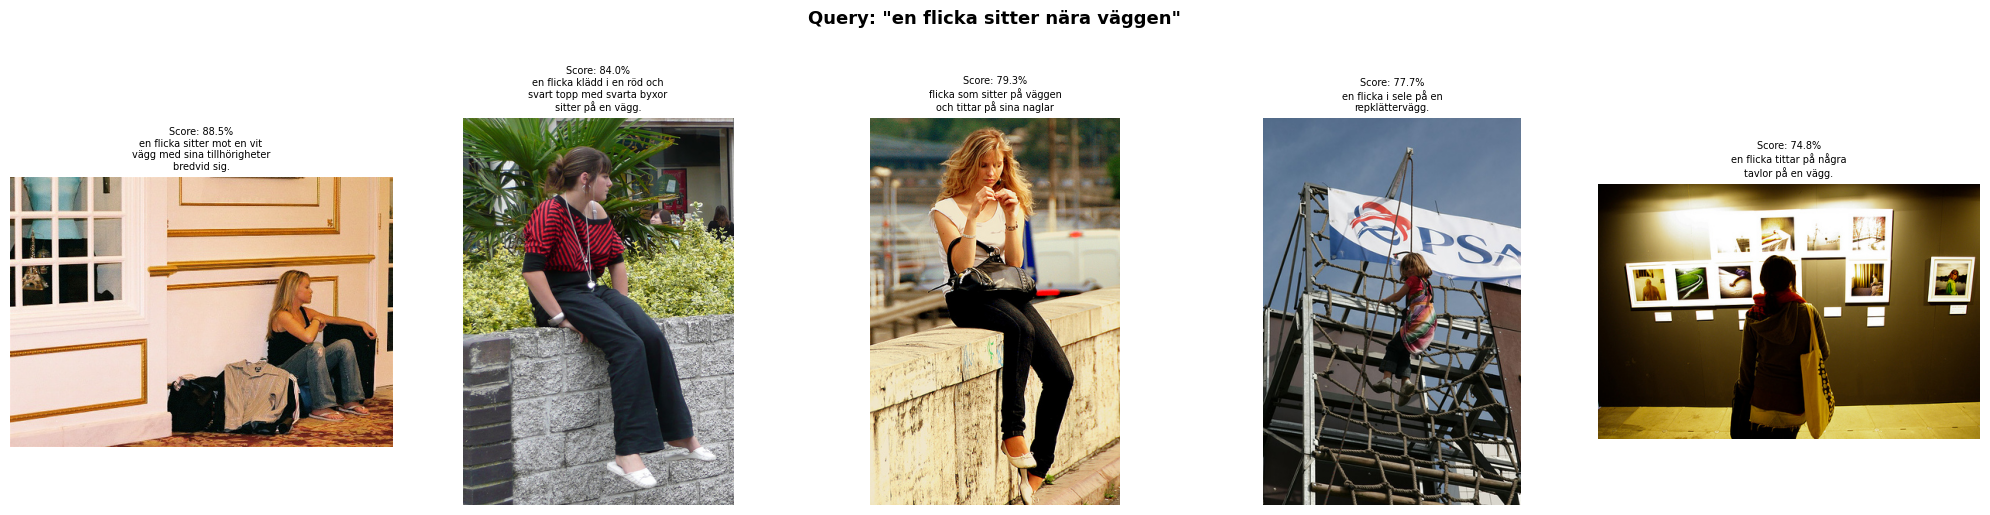


Retrieved 5 images for: 'en flicka sitter nära väggen'
-------------------------------------------------------
  1. Score=0.885 | 290982269_79fc9f36dc.jpg | en flicka sitter mot en vit vägg med sina tillhöri
  2. Score=0.840 | 1295669416_21cabf594d.jpg | en flicka klädd i en röd och svart topp med svarta
  3. Score=0.793 | 2712787899_d85048eb6a.jpg | flicka som sitter på väggen och tittar på sina nag
  4. Score=0.777 | 1463638541_c02cfa04dc.jpg | en flicka i sele på en repklättervägg.
  5. Score=0.748 | 3172369593_eb4d787ffb.jpg | en flicka tittar på några tavlor på en vägg.
-------------------------------------------------------


[{'id': 16735,
  'image_path': 'flickr8k/images\\290982269_79fc9f36dc.jpg',
  'caption': 'en flicka sitter mot en vit vägg med sina tillhörigheter bredvid sig.',
  'score': 0.885118305683136,
  'query': 'en flicka sitter nära väggen',
  'source': 'text'},
 {'id': 1270,
  'image_path': 'flickr8k/images\\1295669416_21cabf594d.jpg',
  'caption': 'en flicka klädd i en röd och svart topp med svarta byxor sitter på en vägg.',
  'score': 0.8396552801132202,
  'query': 'en flicka sitter nära väggen',
  'source': 'text'},
 {'id': 13692,
  'image_path': 'flickr8k/images\\2712787899_d85048eb6a.jpg',
  'caption': 'flicka som sitter på väggen och tittar på sina naglar',
  'score': 0.7931375503540039,
  'query': 'en flicka sitter nära väggen',
  'source': 'text'},
 {'id': 2486,
  'image_path': 'flickr8k/images\\1463638541_c02cfa04dc.jpg',
  'caption': 'en flicka i sele på en repklättervägg.',
  'score': 0.7773540616035461,
  'query': 'en flicka sitter nära väggen',
  'source': 'text'},
 {'id': 21650

In [19]:
# ============================================================
# CELL 16 — Quick test
# ============================================================
text_search("en flicka sitter nära väggen")


  SPEECH SEARCH — Attempt 1/2

Speak in Swedish (7 seconds)
  3...
  2...
  1...
  Recording — SPEAK NOW!
  Recording stopped
  Audio level: 0.0318  Good

Transcribing with Whisper...
  Transcript : 'En man lagar mat.'
  Confidence : 8%

TEXT SEARCH: 'en man lagar mat.'
  Index: 40439 vectors | Top-K: 5 | Threshold: 0.2
Found 5 results


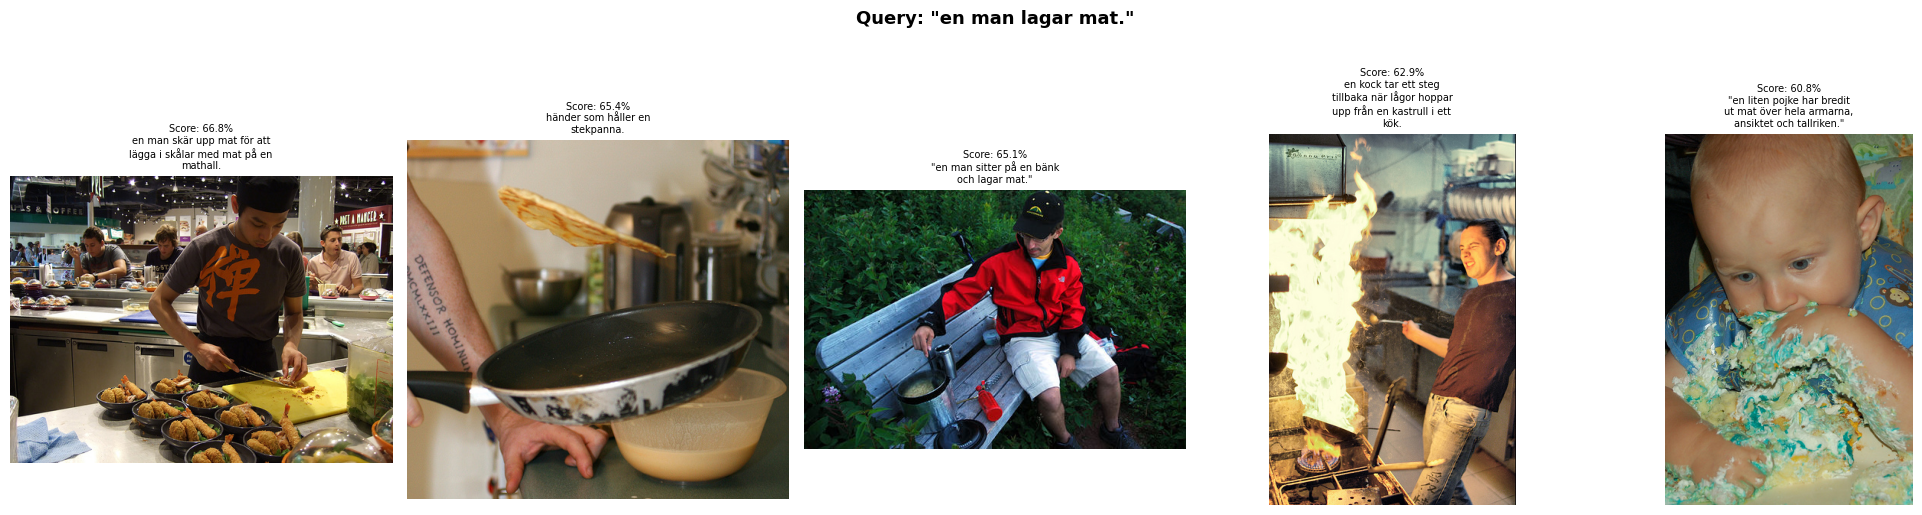


Retrieved 5 images for: 'en man lagar mat.'
-------------------------------------------------------
  1. Score=0.668 | 1472653060_7427d2865a.jpg | en man skär upp mat för att lägga i skålar med mat
  2. Score=0.654 | 3306464579_1b16a0caf2.jpg | händer som håller en stekpanna.
  3. Score=0.651 | 35506150_cbdb630f4f.jpg | "en man sitter på en bänk och lagar mat."
  4. Score=0.629 | 3296124052_6f1d1c9f8d.jpg | en kock tar ett steg tillbaka när lågor hoppar upp
  5. Score=0.608 | 2746072388_b127f8259b.jpg | "en liten pojke har bredit ut mat över hela armarn
-------------------------------------------------------


[{'id': 2601,
  'image_path': 'flickr8k/images\\1472653060_7427d2865a.jpg',
  'caption': 'en man skär upp mat för att lägga i skålar med mat på en mathall.',
  'score': 0.6680783629417419,
  'query': 'en man lagar mat.',
  'source': 'text'},
 {'id': 24918,
  'image_path': 'flickr8k/images\\3306464579_1b16a0caf2.jpg',
  'caption': 'händer som håller en stekpanna.',
  'score': 0.65411776304245,
  'query': 'en man lagar mat.',
  'source': 'text'},
 {'id': 31125,
  'image_path': 'flickr8k/images\\35506150_cbdb630f4f.jpg',
  'caption': '"en man sitter på en bänk och lagar mat."',
  'score': 0.6505218744277954,
  'query': 'en man lagar mat.',
  'source': 'text'},
 {'id': 24730,
  'image_path': 'flickr8k/images\\3296124052_6f1d1c9f8d.jpg',
  'caption': 'en kock tar ett steg tillbaka när lågor hoppar upp från en kastrull i ett kök.',
  'score': 0.6291951537132263,
  'query': 'en man lagar mat.',
  'source': 'text'},
 {'id': 14119,
  'image_path': 'flickr8k/images\\2746072388_b127f8259b.jpg',
 

In [21]:
# ============================================================
# CELL 17 — Voice test
# ============================================================
speech_search(duration=7)